<a href="https://colab.research.google.com/github/tijiyabhanu/HandWritten_digit_classification/blob/main/dogs_vs_cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d salader/dogsVScats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsVScats
License(s): unknown
100% 1.06G/1.06G [00:26<00:00, 43.0MB/s]



In [2]:
mkdir -p ~/.kaggle && echo KGAT_f9b113b64b4d5b649ecb/54779343798 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
import zipfile
import os

zip_ref = zipfile.ZipFile('/content/dogsVScats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [6]:
# Load the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [9]:
model = Sequential(
    [data_augmentation,


# 1st Convolutional Block
Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)),
BatchNormalization(),
MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

# 2nd Convolutional Block
Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
BatchNormalization(),
MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

# 3rd Convolutional Block
Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'),
BatchNormalization(),
MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),

# Flattening and Fully Connected Layers
Flatten(),

Dense(128, activation='relu'),
Dropout(0.1),

Dense(64, activation='relu'),
Dropout(0.1),

# Output Layer for Binary Classification
Dense(1, activation='sigmoid')
    ])
model.summary()

# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 118s 171ms/step - accuracy: 0.5577 - loss: 1.4362 - val_accuracy: 0.6232 - val_loss: 0.6915
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.6258 - loss: 0.6473 - val_accuracy: 0.6618 - val_loss: 0.6084
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 110s 176ms/step - accuracy: 0.6612 - loss: 0.6207 - val_accuracy: 0.6816 - val_loss: 0.5860
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.6903 - loss: 0.5805 - val_accuracy: 0.6852 - val_loss: 0.5965
Epoch 5/10
323/625 ━━━━━━━━━━━━━━━━━━━━ 47s 159ms/step - accuracy: 0.7041 - loss: 0.5779

KeyboardInterrupt: 

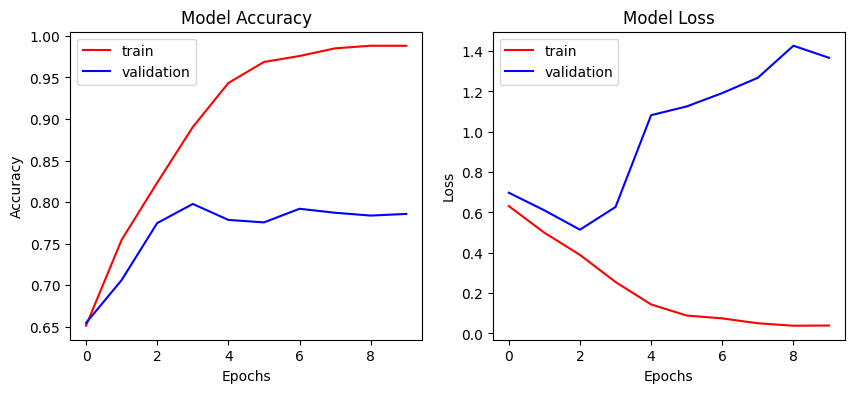

In [ ]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

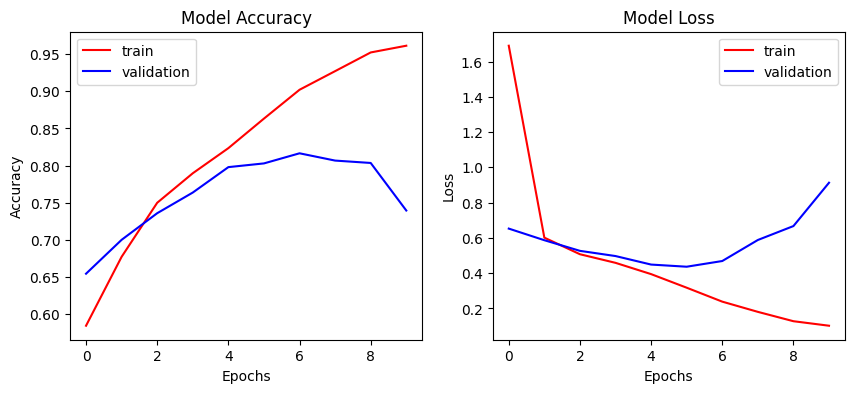

In [ ]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

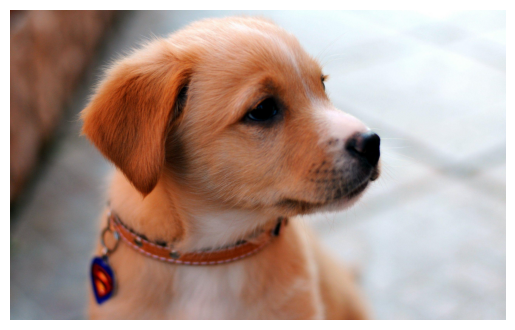

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Raw Prediction Value: 0.32469430565834045
Prediction: It's a CAT!


In [ ]:
# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
# image_path = '/content/dog.10022.jpg'
image_path = "/content/dog1.jpg"

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")

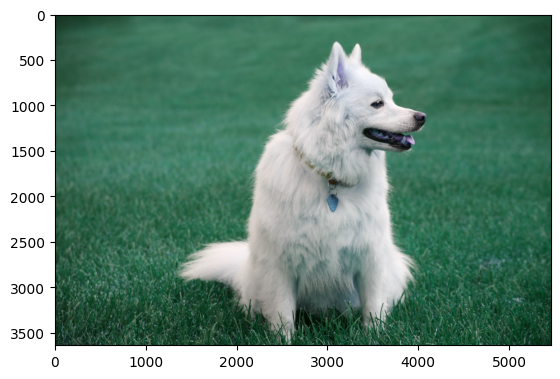

In [ ]:
test_img = cv2.imread('/content/dog2.jpg')
# Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
# test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
plt.imshow(test_img)

In [ ]:
test_img.shape

(3640, 5460, 3)

In [ ]:
test_img = cv2.resize(test_img,(256,256))

In [ ]:
test_img.shape

(256, 256, 3)

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
test_input = test_input / 255.0

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0.16812135]], dtype=float32)

In [ ]:
loss,accuracy = model.evaluate(validation_ds)
print(loss,accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7396 - loss: 0.9130
0.9129732251167297 0.7396000027656555


In [ ]:
predictions = model.predict(validation_ds)
import numpy as np
predicted_classes = np.argmax(predictions,axis=1)
print(predicted_classes)

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step
[0 0 0 ... 0 0 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [ ]:
y_true = []
y_pred = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)

    # For binary classification (Cats vs Dogs)
    predicted = (predictions > 0.5).astype("int32").flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted)

In [ ]:
class_names = ['cats', 'dogs']

for actual, pred in zip(y_true, y_pred):
    print(f"Actual: {class_names[actual]}  |  Predicted: {class_names[pred]}")

Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: dogs
Actual: cats  |  Predicted: dogs
Actual: cats  |  Predicted: dogs
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: cats
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: cats
Actual: dogs  |  Predicted: cats
Actual: cats  |  Predicted: dogs
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: dogs  |  Predicted: cats
Actual: dogs  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: dogs  |  Predicted: dogs
Actual: dogs  |  Predicted: dogs
Actual: cats  |  Predicted: cats
Actual: cats  |  Predicted: cats
Actual: dogs  |  Predicted: cats
Actual: cats  |  Predicted: dogs
Actual: do

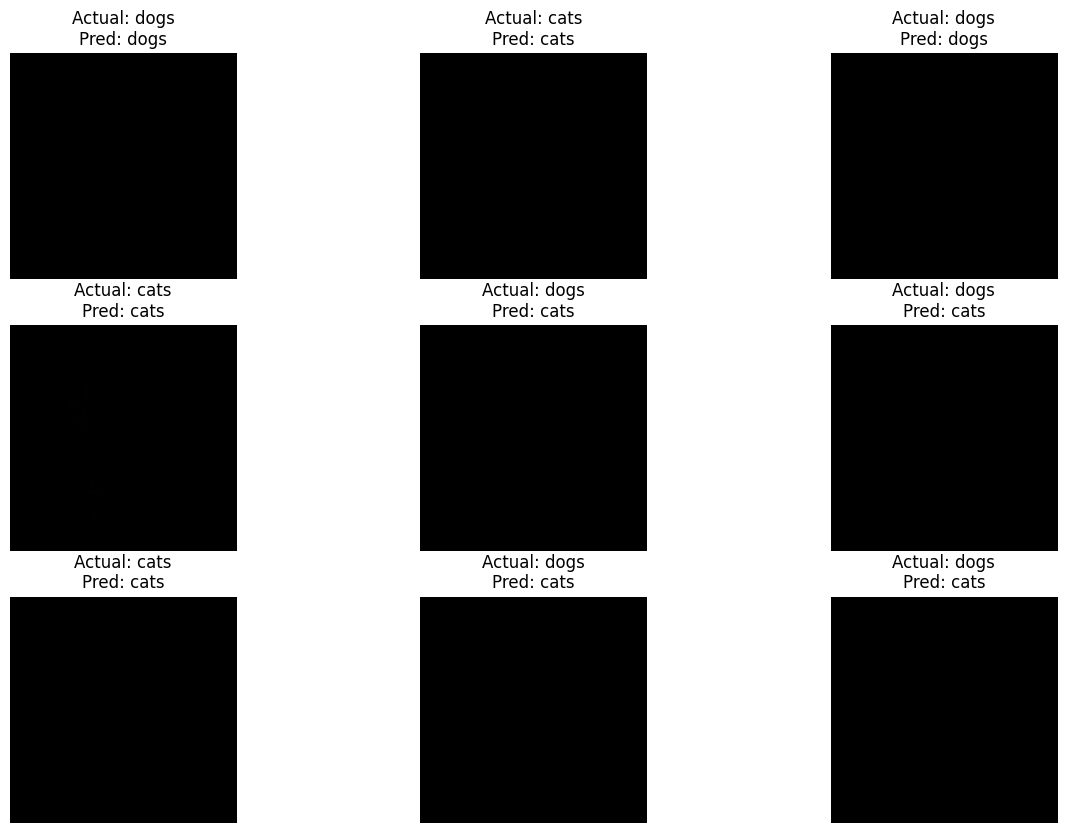

In [ ]:
class_names = ['cats', 'dogs']

for images, labels in validation_ds.take(1):
    predictions = model.predict(images, verbose=0)
    predicted = (predictions > 0.5).astype("int32").flatten()

    plt.figure(figsize=(15, 10))

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Actual: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}"
        )
        plt.axis("off")

    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[2279  221]
 [1081 1419]]
              precision    recall  f1-score   support

        cats       0.68      0.91      0.78      2500
        dogs       0.87      0.57      0.69      2500

    accuracy                           0.74      5000
   macro avg       0.77      0.74      0.73      5000
weighted avg       0.77      0.74      0.73      5000

